# Step 0 — Tooling, data, and question

**The data.** Welltory, 2020: volunteers in an open COVID study logged health in an app. Some also connected a watch or phone. Those daily totals are `data/week4/hrv-covid19-master/data/wearables.csv`. Column names are explained in `data/week4/hrv-covid19-master/datatypes.md`. The CSV itself is only numbers. One row is one person on one day. This notebook uses that wearable table only.

---

**Research question**

<p style="font-size:1.45em;font-weight:800;line-height:1.3;margin:0.4em 0 0.6em">On days with a step count, how many steps did people typically take — and how often did they hit 10,000?</p>

---

10,000 is a common daily walking goal. Step 7 adds a yes/no column for it.

**Tooling.** Built in Cursor (agent chat plus this notebook). Each prompt is logged in `.cursor/DESIGN_LOG.md` as what was asked and why. That log is the short history of the EDA: the Welltory dump was opened, then narrowed from HRV and sleep/blood pressure to daily steps; pandas checked size, blanks, and typical step days; matplotlib charts were saved as images so they show here; cleaning dropped blank steps (not filled with zero) and tagged high days instead of deleting them; a calories-per-step idea was tried and dropped as not plausible; the feature that remained is the 10,000-step yes/no. AI-driven via Cursor.

# Step 1 — What is in the file, and why steps?

Names below follow `datatypes.md`. Each row is one person on one day.

- `user_code` — who  
- `day` — the date  
- `resting_pulse`, `pulse_average`, `pulse_min`, `pulse_max` — heart rate  
- `average_spo2_value` — blood oxygen  
- `body_temperature_avg` — temperature  
- `stand_hours_total` — hours standing  
- `steps_count` — steps that day  
- `distance` — walking or running distance (meters)  
- `steps_speed` — steps per minute  
- `total_number_of_flights_climbed` — flights of stairs  
- `active_calories_burned`, `basal_calories_burned`, `total_calories_burned` — calories  
- `average_headphone_exposure`, `average_environment_exposure` — noise  

A blank cell means nothing was recorded that day, not zero.

**Steps** is the focus. Rationale: it is a direct watch count, easy to read, and 10,000 is a goal people already know. Other columns stay in the file for context but are not the question.

# Step 2 — Who is in this data?

These are study volunteers who connected a watch or phone, not a random sample of everyone with COVID.

The sample for the question is **days with a recorded step count**. Anyone who never sent steps is out.

# Step 3 — Open the file. What is in it?

Load `wearables.csv`, then check size, blanks, and what recorded step days look like. A short correlation with distance checks that two walk measures move together.

In [1]:
# Load wearables.csv (notebook folder or repo root).
from pathlib import Path

import pandas as pd

DATA = Path("../data/week4/hrv-covid19-master/data/wearables.csv")
if not DATA.exists():
    DATA = Path("data/week4/hrv-covid19-master/data/wearables.csv")

w = pd.read_csv(DATA, parse_dates=["day"])
w.head()

,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure
0,007b8190cf,2020-04-26,NaN,70.0,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2859.0,2859.0,NaN,NaN
1,01bad5a519,2020-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8574.0,NaN,57.90,NaN,NaN,2624.0,2624.0,NaN,NaN
2,01bad5a519,2020-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7462.0,NaN,59.10,NaN,NaN,2624.0,2624.0,NaN,NaN
3,01bad5a519,2020-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507.0,NaN,60.97,NaN,NaN,2624.0,2624.0,NaN,NaN
4,01bad5a519,2020-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10131.0,NaN,49.10,NaN,NaN,2624.0,2624.0,NaN,NaN


In [2]:
# Row count, people, date range, and any repeated person-days.
print("rows", len(w), "people", w.user_code.nunique())
print("days", w.day.min().date(), "→", w.day.max().date())
print("same person on the same day more than once", w.duplicated(["user_code", "day"]).sum())
print("columns", list(w.columns))

rows 3098 people 79
days 2020-01-01 → 2020-06-19
same person on the same day more than once 0
columns ['user_code', 'day', 'resting_pulse', 'pulse_average', 'pulse_min', 'pulse_max', 'average_spo2_value', 'body_temperature_avg', 'stand_hours_total', 'steps_count', 'distance', 'steps_speed', 'total_number_of_flights_climbed', 'active_calories_burned', 'basal_calories_burned', 'total_calories_burned', 'average_headphone_exposure', 'average_environment_exposure']


In [3]:
# Percent blank per column, then summarize days that have a step count.
print("percent blank")
print((w.isna().mean() * 100).round(1).sort_values(ascending=False).to_string())

steps = w.loc[w["steps_count"].notna(), "steps_count"]
print()
print("days with steps", len(steps), "people with steps", w.loc[w["steps_count"].notna(), "user_code"].nunique())
print(steps.describe().round(1).to_string())

percent blank
average_spo2_value                 98.7
body_temperature_avg               97.9
average_environment_exposure       95.2
average_headphone_exposure         92.6
stand_hours_total                  82.9
active_calories_burned             61.3
total_number_of_flights_climbed    60.1
steps_speed                        54.2
resting_pulse                      51.1
distance                           39.7
steps_count                        36.5
pulse_max                          32.6
pulse_min                          32.6
pulse_average                      32.6
day                                 0.0
basal_calories_burned               0.0
total_calories_burned               0.0
user_code                           0.0

days with steps 1968 people with steps 33
count     1968.0
mean      5342.1
std       4761.8
min          1.0
25%       1456.0
50%       4477.5
75%       7857.2
max      30882.0


In [4]:
# Steps vs distance on days that have both (same walk, two measures).
both = w.dropna(subset=["steps_count", "distance"])
print("steps vs distance (n =", len(both), ") corr =", round(both["steps_count"].corr(both["distance"]), 3))

steps vs distance (n = 1710 ) corr = 0.829


**What the file shows.** One row is one person on one day. No one appears twice on the same date. The window is early 2020. Only some of the 79 people have a step count.

Most step days are a few thousand steps, not 10,000. A few very high days pull the average up.

Many columns are mostly blank (oxygen, temperature, sound): the gadget did not send that field. A blank step count is not zero.

Steps and distance usually rise together, as expected if both came from the same walk.

# Step 4 — What do daily steps look like on a chart?

Two visualizations of recorded step days. Rationale: the histogram shows where a typical day sits relative to 10,000; the bar chart counts how many days are under vs at the goal.

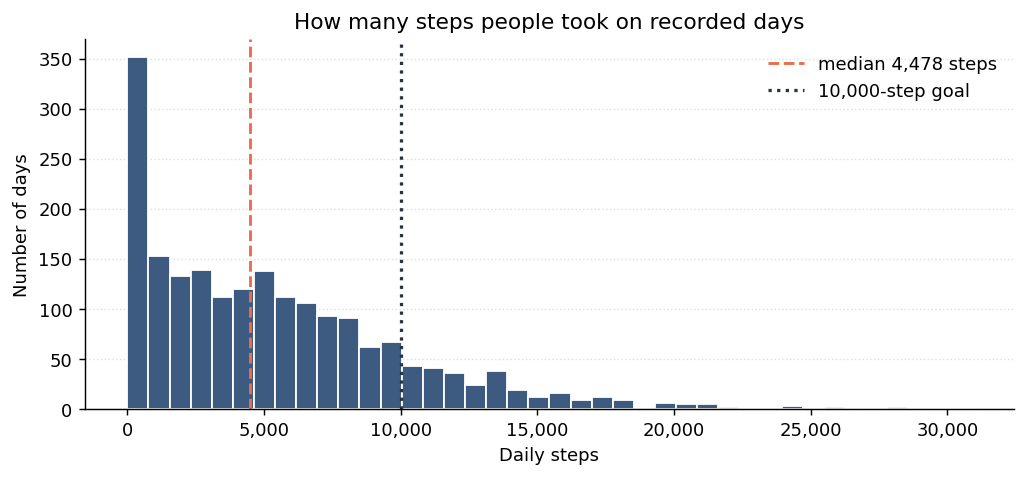

In [5]:
# Histogram of daily steps; mark the median and the 10,000-step goal.
from io import BytesIO

import IPython.core.pylabtools as _pylabtools
if not hasattr(_pylabtools, "backend2gui"):
    _pylabtools.backend2gui = {}

import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.ticker import FuncFormatter

BLUE, ACCENT, GOAL = "#3d5a80", "#ee6c4d", "#293241"


def show_fig(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor="white")
    display(Image(data=buf.getvalue()))


def comma_axis(ax, which="x"):
    fmt = FuncFormatter(lambda v, _: f"{v:,.0f}")
    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(fmt)
    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(fmt)


s = w.loc[w["steps_count"].notna(), "steps_count"]
plt.figure(figsize=(8, 3.8), facecolor="white")
plt.hist(s, bins=40, color=BLUE, edgecolor="white")
plt.axvline(s.median(), color=ACCENT, linestyle="--", linewidth=1.6, label=f"median {s.median():,.0f} steps")
plt.axvline(10000, color=GOAL, linestyle=":", linewidth=1.8, label="10,000-step goal")
plt.xlabel("Daily steps")
plt.ylabel("Number of days")
plt.title("How many steps people took on recorded days")
ax = plt.gca()
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
comma_axis(ax, "both")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(frameon=False)
plt.tight_layout()
show_fig(plt.gcf())
plt.close()


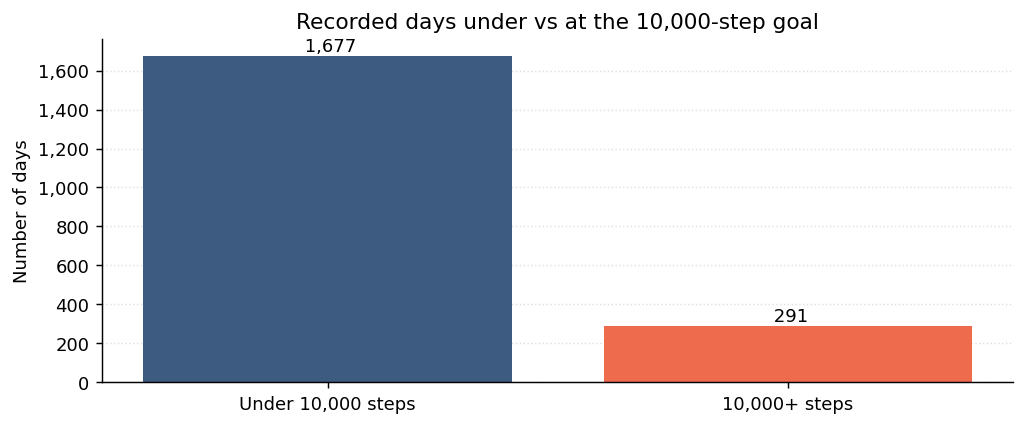

In [6]:
# Second chart: count of days under 10,000 vs at or above 10,000.
s = w.loc[w["steps_count"].notna(), "steps_count"]
n_under = int((s < 10000).sum())
n_hit = int((s >= 10000).sum())
plt.figure(figsize=(8, 3.4), facecolor="white")
plt.bar(["Under 10,000 steps", "10,000+ steps"], [n_under, n_hit], color=[BLUE, ACCENT])
plt.ylabel("Number of days")
plt.title("Recorded days under vs at the 10,000-step goal")
ax = plt.gca()
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
comma_axis(ax, "y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for i, n in enumerate([n_under, n_hit]):
    plt.text(i, n, f" {n:,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
show_fig(plt.gcf())
plt.close()


Most days are a few thousand steps. The 10,000 line sits to the right of the median, so a typical recorded day is under the common goal. The bar chart matches that: far more days sit under 10,000 than at it.

# Step 5 — Missing values, duplicate records, and outliers

Cleaned rows go in `d`. The original table stays in `w`.

**Duplicate records.** Investigate with `duplicated()`, then address with `drop_duplicates` on person and date. There were none; the drop still runs so duplicate records are handled, not only counted. Rationale: one person should appear once per day.

**Missing values.** Drop days with no step count. Rationale: a blank is not zero, and filling zero would invent quiet days. Other blanks are left as-is.

**Outliers.** Tag days above about 17,500 steps (`steps_high`) and keep them. Rationale: a long walking day is still a real day. Hitting 10,000 is the later new feature, not an outlier cutoff.

In [7]:
# Investigate duplicate records, then drop them.
print("duplicate rows", int(w.duplicated().sum()))
print("duplicate person-days", int(w.duplicated(["user_code", "day"]).sum()))
d = w.drop_duplicates().copy()
d = d.drop_duplicates(["user_code", "day"])
print("rows after drop_duplicates", len(d))

duplicate rows 0
duplicate person-days 0
rows after drop_duplicates 3098


In [8]:
# Keep days with a recorded step count. Do not turn blanks into zero.
n_before = len(d)
d = d.loc[d["steps_count"].notna()].copy()
print("rows before dropping blank steps", n_before)
print("rows after", len(d), "people", d.user_code.nunique())
print("blank steps left", int(d["steps_count"].isna().sum()))

rows before dropping blank steps 3098
rows after 1968 people 33
blank steps left 0


In [9]:
# Tag unusually high step days; keep them in the table.
q1 = d["steps_count"].quantile(0.25)
q3 = d["steps_count"].quantile(0.75)
iqr = q3 - q1
hi = q3 + 1.5 * iqr
d["steps_high"] = d["steps_count"] > hi
print("usual range cutoff", round(hi, 1))
print("high days tagged", int(d["steps_high"].sum()), "of", len(d))
print("highest steps kept", int(d["steps_count"].max()))

usual range cutoff 17459.1
high days tagged 44 of 1968
highest steps kept 30882


`d` is 1,968 days, 33 people, every row has steps, no repeats, and 44 high days tagged instead of deleted.

# Step 6 — Put each person’s days in order

Sort by person and date so each person’s days sit in a line and are easier to read before the 10k flag is added.

In [10]:
# Sort by person, then date.
d = d.sort_values(["user_code", "day"]).reset_index(drop=True)
print("rows", len(d))
print(d[["user_code", "day", "steps_count"]].head().to_string(index=False))

rows 1968
 user_code        day  steps_count
01bad5a519 2020-02-12       8574.0
01bad5a519 2020-02-13       7462.0
01bad5a519 2020-02-15       2507.0
01bad5a519 2020-02-16      10131.0
01bad5a519 2020-02-17       8086.0


# Step 7 — New feature: hit 10,000 steps

This step creates a new feature, `hit_10000`: 1 if that day has at least 10,000 steps, else 0.

Rationale: 10,000 is a common daily goal, and most days in this file sit below it. Each person then gets a share: what fraction of their step days hit 10,000.

In [11]:
# Create the new feature, then each person's share of days that hit it.
d["hit_10000"] = (d["steps_count"] >= 10000).astype(int)

person = (
    d.groupby("user_code", as_index=False)
    .agg(
        days=("day", "size"),
        avg_steps=("steps_count", "mean"),
        hit_days=("hit_10000", "sum"),
    )
)
person["share_10k"] = person["hit_days"] / person["days"]

print("new feature hit_10000: 0/1 for 10,000+ steps that day")
print("step days", len(d), "days at 10,000+", int(d["hit_10000"].sum()), f"({d['hit_10000'].mean():.1%})")
print("people with at least one 10k day", int((person["hit_days"] > 0).sum()), "of", len(person))
print()
print(person.sort_values("share_10k")[["user_code", "days", "avg_steps", "hit_days", "share_10k"]].round(3).to_string(index=False))

new feature hit_10000: 0/1 for 10,000+ steps that day
step days 1968 days at 10,000+ 291 (14.8%)
people with at least one 10k day 24 of 33

 user_code  days  avg_steps  hit_days  share_10k
f9edcb7056    18   2401.889         0      0.000
1942df1c47    28    813.964         0      0.000
276ab22485    18    894.278         0      0.000
42a99d8248    54    935.259         0      0.000
cdfbcad405    28   3746.036         0      0.000
b9b65b7a69    75    426.680         0      0.000
b523b4512b    55   2960.491         0      0.000
5efbee746a    32   1042.438         0      0.000
7ba5381254    33   3336.848         0      0.000
c174f32d88   151   3749.775         2      0.013
ebf2c3cb63    89   3061.562         2      0.022
fde84801d8    51   3826.098         2      0.039
0f2d7af30c    20   1468.000         1      0.050
71980b2daf    58   3165.034         3      0.052
9871ee5e7b    54   3105.481         3      0.056
ad41d5b79c    70   6553.671         5      0.071
35c7355282    23   2655.087

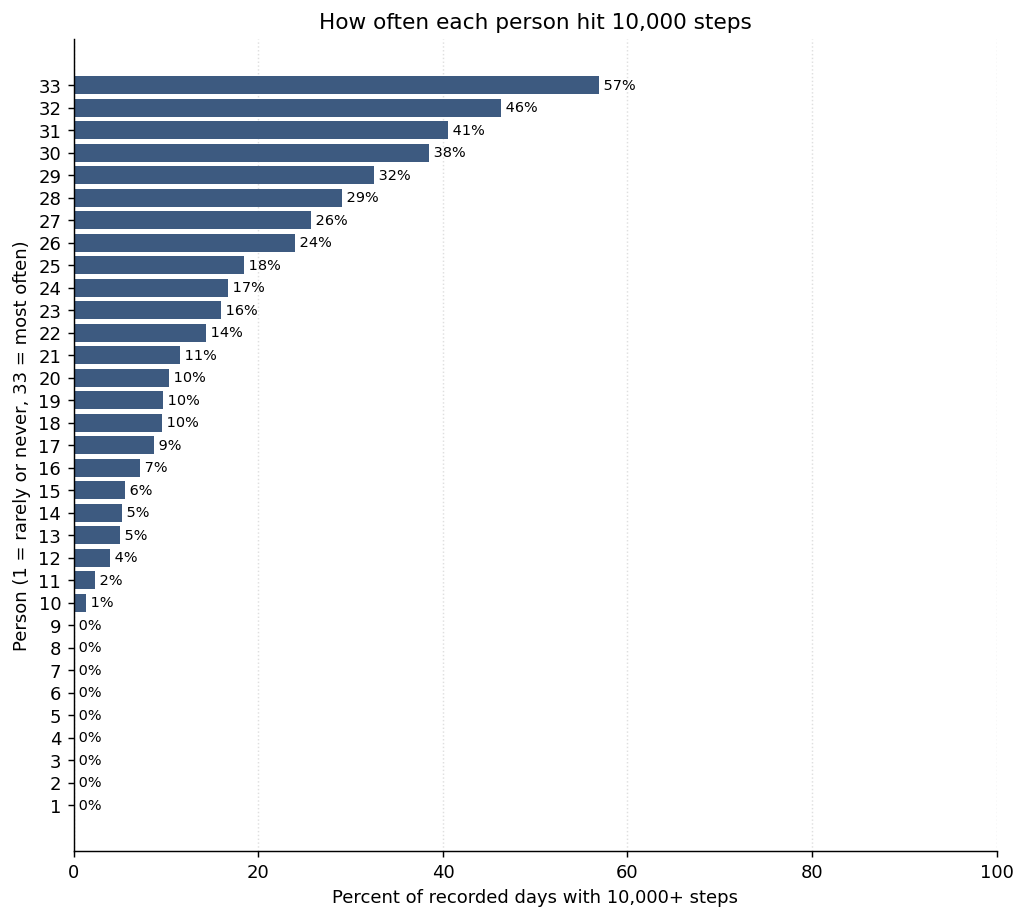

In [12]:
# One bar per person: percent of recorded days at 10,000+ steps.
p = person.sort_values("share_10k").reset_index(drop=True)
plt.figure(figsize=(8, 7.2), facecolor="white")
y = range(len(p))
pct = p["share_10k"] * 100
plt.barh(list(y), pct, color=BLUE)
ax = plt.gca()
ax.set_yticks(list(y))
ax.set_yticklabels([str(i + 1) for i in y])
plt.xlabel("Percent of recorded days with 10,000+ steps")
plt.ylabel("Person (1 = rarely or never, 33 = most often)")
plt.title("How often each person hit 10,000 steps")
ax.set_xlim(0, 100)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle=":", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for i, val in enumerate(pct):
    plt.text(val, i, f" {val:.0f}%", va="center", fontsize=8)
plt.tight_layout()
show_fig(plt.gcf())
plt.close()


The new feature `hit_10000` is 1 when the day is at least 10,000 steps. About 15% of step days hit it. Some people never do; a few do on about half of their days.

# Step 8 — Data quality

**Profiling.** 3,098 person-days, 79 people, January–June 2020; 1,968 of those days (33 people) have a step count.

**Completeness.** Steps are blank on about one in three rows; those days are dropped, because a blank is not zero.

**Accuracy.** Typical recorded days are a few thousand steps, which looks like real walking, not a sensor crash.

**Consistency.** Steps and distance rise together (correlation about 0.83) on days that have both.

**Integrity.** No person appears twice on the same date.

**Where the data came from (lineage / provenance).** Welltory’s 2020 open COVID wearable dump; this notebook reads `wearables.csv` from that unzipped folder.

# Conclusion

On recorded days, people typically took about 4,500 steps — under the 10,000 goal. About 15% of those days hit 10,000; 9 of 33 people never did, and a few hit it on about half their days. `hit_10000` is the yes/no flag for that goal.

The step picture is incomplete. About one in three wearable days has no step count (those days are dropped; a blank is not zero). Only 33 of 79 people ever sent steps, and they are volunteers with a connected gadget, not a random sample of the COVID study. Other fields (oxygen, temperature, sound) are mostly empty and were not used.